In [2]:
! pip install xgboost

In [3]:
# Import necessary Libraries

import pandas as  pd
import numpy as np

In [4]:
# Load the dataset and preprocessing

df=pd.read_csv("df_yield_merged.csv")
df

,area,year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,item,value_hg_ha
0,Albania,1990,1485.0,121.00,16.37,Maize,36613
1,Albania,1990,1485.0,121.00,16.37,Potatoes,66667
2,Albania,1990,1485.0,121.00,16.37,"Rice, paddy",23333
3,Albania,1990,1485.0,121.00,16.37,Sorghum,12500
4,Albania,1990,1485.0,121.00,16.37,Soybeans,7000
...,...,...,...,...,...,...,...
25927,Zimbabwe,2013,657.0,2550.07,19.76,"Rice, paddy",22581
25928,Zimbabwe,2013,657.0,2550.07,19.76,Sorghum,3066
25929,Zimbabwe,2013,657.0,2550.07,19.76,Soybeans,13142
25930,Zimbabwe,2013,657.0,2550.07,19.76,Sweet potatoes,22222


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25932 entries, 0 to 25931
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   area                           25932 non-null  object 
 1   year                           25932 non-null  int64  
 2   average_rain_fall_mm_per_year  25932 non-null  float64
 3   pesticides_tonnes              25932 non-null  float64
 4   avg_temp                       25932 non-null  float64
 5   item                           25932 non-null  object 
 6   value_hg_ha                    25932 non-null  int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 1.4+ MB


In [6]:
df.describe()

,year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,value_hg_ha
count,25932.000000,25932.000000,25932.000000,25932.000000,25932.000000
mean,2001.556455,1146.836688,34782.573241,20.422251,76978.132925
std,7.055924,717.391098,57228.568244,6.439402,84647.605552
min,1990.000000,51.000000,0.040000,1.300000,50.000000
25%,1995.000000,593.000000,1597.000000,16.580000,19996.000000
50%,2001.000000,1083.000000,15373.000000,21.420000,39530.000000
75%,2008.000000,1668.000000,45620.000000,26.060000,104168.000000
max,2013.000000,3240.000000,367778.000000,30.650000,501412.000000


In [7]:
df.isnull().sum()

area                             0
year                             0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
item                             0
value_hg_ha                      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: >

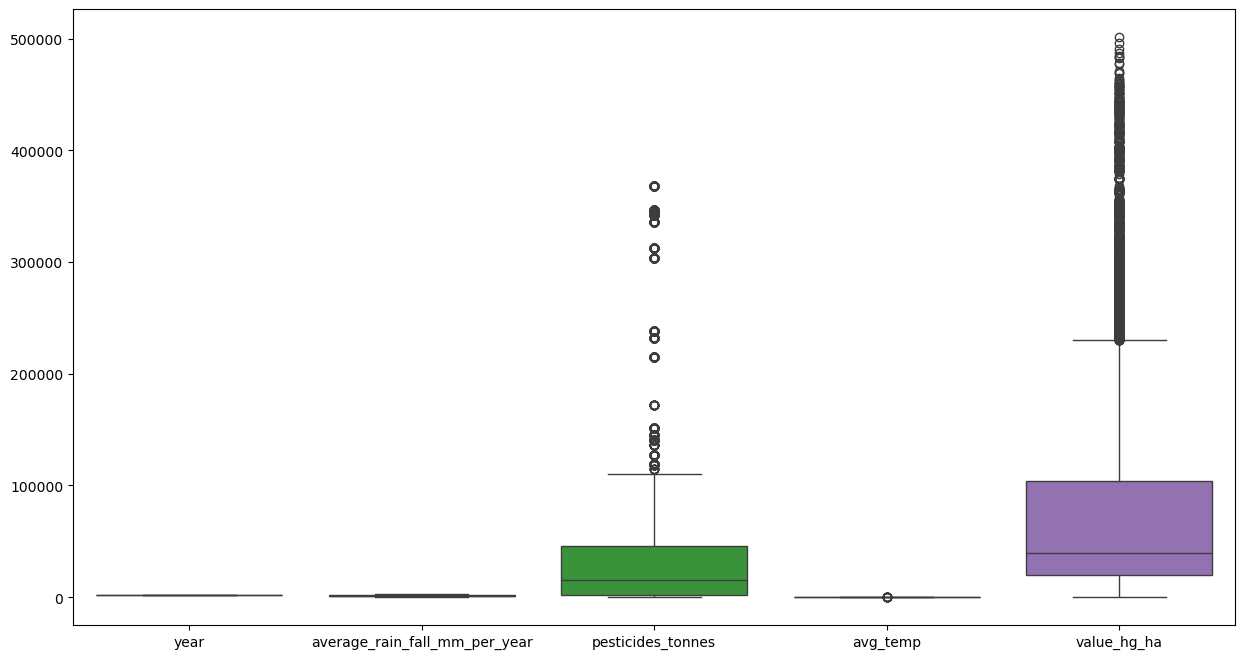

In [10]:
plt.figure(figsize=(15, 8))
sns.boxplot(data = df)

<Axes: xlabel='value_hg_ha', ylabel='Count'>

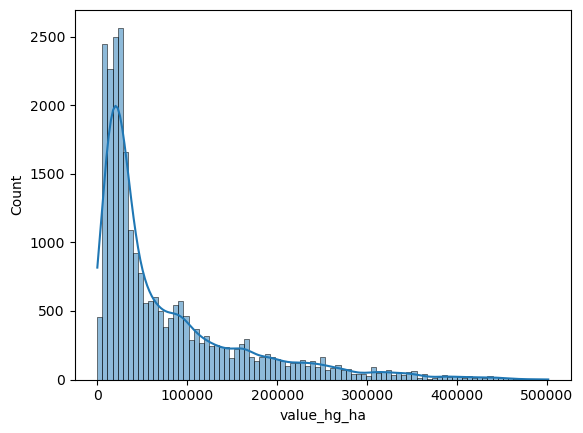

In [11]:
sns.histplot(data = df, x = "value_hg_ha", kde = True)

In [12]:
df_corr = df.select_dtypes(include = ["number"])
df_corr.corr()

,year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,value_hg_ha
year,1.000000,-0.006423,0.135127,0.013701,0.091327
average_rain_fall_mm_per_year,-0.006423,1.000000,0.161483,0.333694,-0.004067
pesticides_tonnes,0.135127,0.161483,1.000000,0.045577,0.065523
avg_temp,0.013701,0.333694,0.045577,1.000000,-0.110400
value_hg_ha,0.091327,-0.004067,0.065523,-0.110400,1.000000


<Axes: >

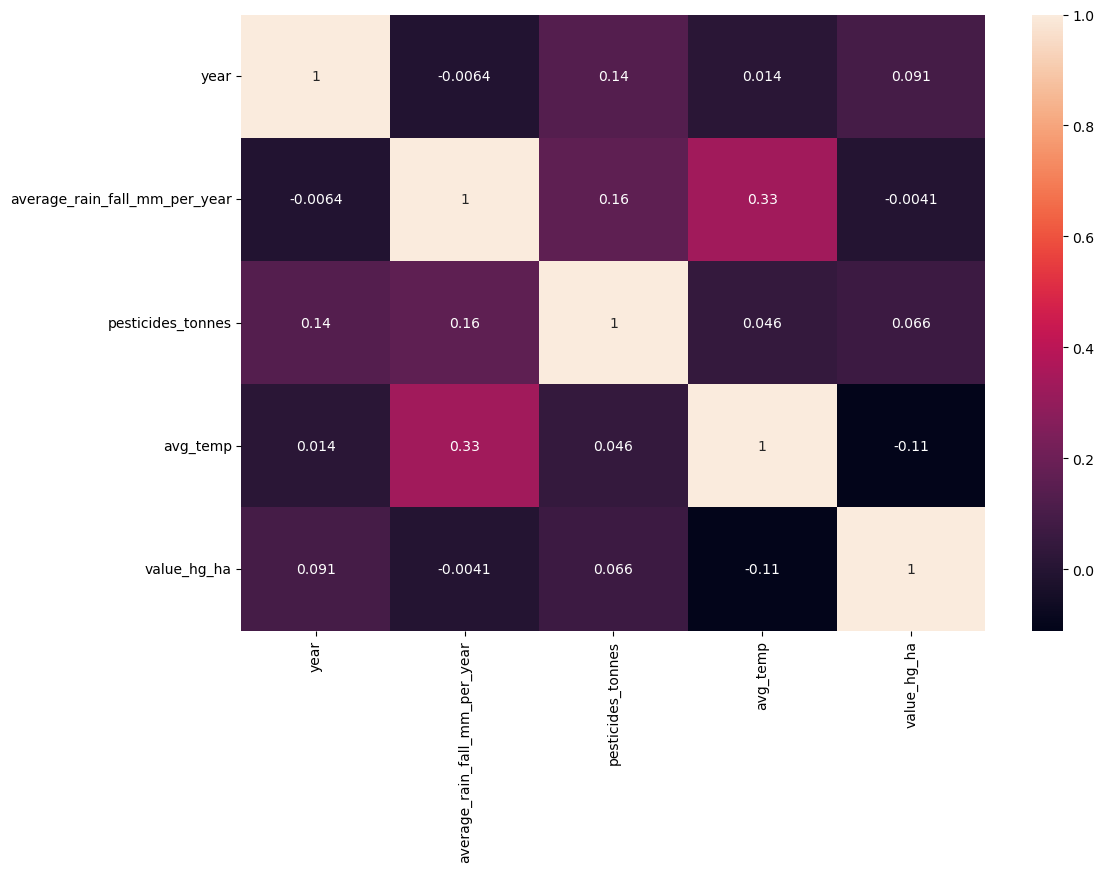

In [13]:
plt.figure(figsize=(12, 8)) 
sns.heatmap(df_corr.corr(), annot = True)

In [14]:
# Encoding the categorical data to numerical data

from sklearn.preprocessing import StandardScaler, LabelEncoder
for col in df.select_dtypes(include = ["object"]).columns:
    l = LabelEncoder()  #calling Function
    l.fit(df[col])  # to fit the data to the function
    df[col] = l.transform(df[col])  # transforming to numerical data


df

,area,year,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp,item,value_hg_ha
0,0,1990,1485.0,121.00,16.37,1,36613
1,0,1990,1485.0,121.00,16.37,3,66667
2,0,1990,1485.0,121.00,16.37,4,23333
3,0,1990,1485.0,121.00,16.37,5,12500
4,0,1990,1485.0,121.00,16.37,6,7000
...,...,...,...,...,...,...,...
25927,100,2013,657.0,2550.07,19.76,4,22581
25928,100,2013,657.0,2550.07,19.76,5,3066
25929,100,2013,657.0,2550.07,19.76,6,13142
25930,100,2013,657.0,2550.07,19.76,7,22222


In [15]:
# Splitting the data into independent and dependent features

x = df.drop("value_hg_ha", axis = 1)  # Independent Col.
y = df["value_hg_ha"]  # Dependent Col.

print(x)
print(y)

       area  year  average_rain_fall_mm_per_year  pesticides_tonnes  avg_temp  \
0         0  1990                         1485.0             121.00     16.37   
1         0  1990                         1485.0             121.00     16.37   
2         0  1990                         1485.0             121.00     16.37   
3         0  1990                         1485.0             121.00     16.37   
4         0  1990                         1485.0             121.00     16.37   
...     ...   ...                            ...                ...       ...   
25927   100  2013                          657.0            2550.07     19.76   
25928   100  2013                          657.0            2550.07     19.76   
25929   100  2013                          657.0            2550.07     19.76   
25930   100  2013                          657.0            2550.07     19.76   
25931   100  2013                          657.0            2550.07     19.76   

       item  
0         1  

In [16]:
# Train Test Split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.8, random_state = 95)

In [17]:
#  Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor()
rf_model.fit( x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

In [18]:
# Evaluation of the RFRegressor model

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [19]:
print(f'Random Forest Regressor Model Performance:')
print(f'Mean Absolute Error: {mae_rf}')
print(f'Mean Squared Error: {mse_rf}')
print(f'R-squared: {r2_rf}')

Random Forest Regressor Model Performance:
Mean Absolute Error: 4033.3749411991516
Mean Squared Error: 104120003.37006843
R-squared: 0.9852371220104221


In [20]:
# XGBoost Regressor

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,         # 1️⃣ Number of trees
    learning_rate=0.15,       # 2️⃣ How fast to learn
    max_depth=5,              # 3️⃣ Tree complexity
    min_child_weight=5,       # 4️⃣ Prevent overfitting
    early_stopping_rounds=20  # 5️⃣ STOP when no improvement
)
xgb_model.fit(
    x_train, 
    y_train,
    eval_set=[(x_test, y_test)],  # Monitor performance on test set
    verbose=20                    # Print progress every 10 rounds
)
y_pred_xgb = xgb_model.predict(x_test)

[0]	validation_0-rmse:74638.90028
[20]	validation_0-rmse:30183.53626
[40]	validation_0-rmse:25487.60901
[60]	validation_0-rmse:22807.13147
[80]	validation_0-rmse:21040.31990
[100]	validation_0-rmse:20104.70004
[120]	validation_0-rmse:19147.79612
[140]	validation_0-rmse:18334.23441
[160]	validation_0-rmse:17754.87768
[180]	validation_0-rmse:17077.64493
[200]	validation_0-rmse:16663.36264
[220]	validation_0-rmse:16328.25179
[240]	validation_0-rmse:15993.97543
[260]	validation_0-rmse:15634.92025
[280]	validation_0-rmse:15225.36079
[300]	validation_0-rmse:14981.82353
[320]	validation_0-rmse:14797.70452
[340]	validation_0-rmse:14623.50600
[360]	validation_0-rmse:14379.53267
[380]	validation_0-rmse:14218.94064
[400]	validation_0-rmse:14038.85263
[420]	validation_0-rmse:13938.57186
[440]	validation_0-rmse:13836.85326
[460]	validation_0-rmse:13721.64099
[480]	validation_0-rmse:13641.34649
[499]	validation_0-rmse:13584.90472


In [21]:
# Evaluation of the XGBoost Regressor model

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

In [22]:
print(f'XGBoost Regressor Model Performance:')
print(f'Mean Absolute Error: {mae_xgb}')
print(f'Mean Squared Error: {mse_xgb}')
print(f'R-squared: {r2_xgb}')

XGBoost Regressor Model Performance:
Mean Absolute Error: 8095.013671875
Mean Squared Error: 184520112.0
R-squared: 0.9738374352455139


In [23]:
import pickle
pickle.dump(rf_model, open("rf_model.pkl", "wb"))
pickle.dump(xgb_model, open("xgb_model.pkl", "wb"))